<a href="https://colab.research.google.com/github/Bryan0324/everyday_coding/blob/main/2026/06/15/day1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
%pip install numpy pytorch matplotlib torchvision
# https://zh.d2l.ai/chapter_multilayer-perceptrons/mlp-concise.html

  Using cached pytorch-1.0.2.tar.gz (689 bytes)
  Preparing metadata (setup.py) ... done
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for pytorch
  Running setup.py clean for pytorch
Failed to build pytorch
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (pytorch)


In [ ]:
import numpy as np
import torch
from torch import nn
import torchvision
from torch.utils import data
from torchvision import transforms
import matplotlib.pyplot as plt

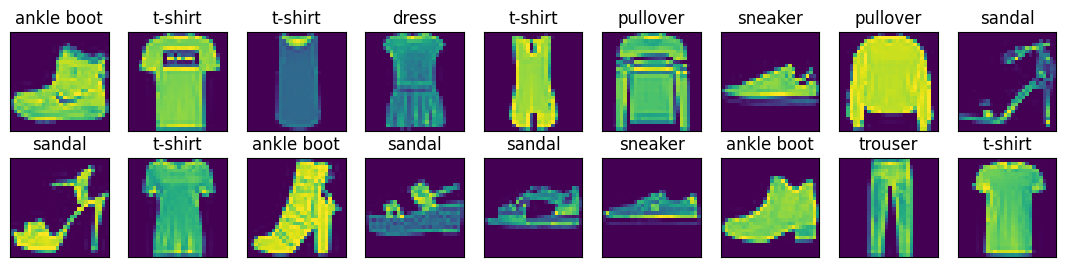

In [6]:
# PIL -> 32bit float
trans = transforms.ToTensor()

# 下載 FashionMNIST 資料集 
mnist_train = torchvision.datasets.FashionMNIST(
    root="../data", train=True, transform=trans, download=True)
mnist_test = torchvision.datasets.FashionMNIST(
    root="../data", train=False, transform=trans, download=True)


def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    figsize = (num_cols * scale, num_rows * scale)

    # subplots 子圖(網格), num_rows, num_cols -> 網格的列數, 欄數
    # figsize -> 子圖大小
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    # axes -> 子圖陣列
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            ax.imshow(img.numpy())
        else:
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes
def get_fashion_mnist_labels(labels):
    """將資料集中的labels和實際名稱對應"""
    text_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
                   'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [text_labels[int(i)] for i in labels]

X, y = next(iter(data.DataLoader(mnist_train, batch_size=18)))
show_images(X.reshape(18, 28, 28), 2, 9, titles=get_fashion_mnist_labels(y))

In [12]:
# 訓練的batch大小, 步伐, 最大訓練次數
batch_size, lr, num_epochs = 256, 0.1, 20

# 定義模型
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Linear(256, 10)
)

def init_weight(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

# 對於model中的每一層使用init_weight
model.apply(init_weight)

# 損失函數, reduction='mean' -> 會壓縮資訊
loss = nn.CrossEntropyLoss(reduction="none")

# 訓練方式
trainer = torch.optim.SGD(model.parameters(), lr=lr)

train_iter = data.DataLoader(mnist_train, batch_size, shuffle=True,
                             num_workers=4)
test_iter = data.DataLoader(mnist_test, batch_size, shuffle=True,
                             num_workers=4)


train_loss_history = []
test_loss_history = []
for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0.0
    total_train_samples = 0
    for X, y in train_iter:
        y_hat = model(X)
        l = loss(y_hat, y)
        trainer.zero_grad()
        l.mean().backward()
        trainer.step()

        # 記錄訓練 Loss
        total_train_loss += l.sum().item()
        total_train_samples += y.size(0)
    
    # 計算該 Epoch 的平均訓練 Loss
    epoch_train_loss = total_train_loss / total_train_samples
    train_loss_history.append(epoch_train_loss)

    model.eval()
    total_test_loss = 0.0
    total_test_samples = 0
    
    with torch.no_grad():         # 關閉梯度計算，節省記憶體
        for X_test, y_test in test_iter:
            y_hat_test = model(X_test)
            l_test = loss(y_hat_test, y_test)
            # 因為 reduction='none'，我們把這個 Batch 的 Loss 加總起來
            total_test_loss += l_test.sum().item()
            total_test_samples += y_test.size(0)
            
    # 計算該 Epoch 的平均測試 Loss
    epoch_test_loss = total_test_loss / total_test_samples
    test_loss_history.append(epoch_test_loss)
    
    print(f'epoch {epoch + 1}, test loss {epoch_test_loss:.4f}')



epoch 1, test loss 0.7222
epoch 2, test loss 0.6757
epoch 3, test loss 0.6343
epoch 4, test loss 0.4976
epoch 5, test loss 0.4701
epoch 6, test loss 0.4613
epoch 7, test loss 0.4620
epoch 8, test loss 0.4273
epoch 9, test loss 0.4266
epoch 10, test loss 0.4487
epoch 11, test loss 0.4506
epoch 12, test loss 0.4128
epoch 13, test loss 0.3958
epoch 14, test loss 0.4112
epoch 15, test loss 0.4282
epoch 16, test loss 0.3959
epoch 17, test loss 0.3726
epoch 18, test loss 0.4152
epoch 19, test loss 0.3961
epoch 20, test loss 0.3805


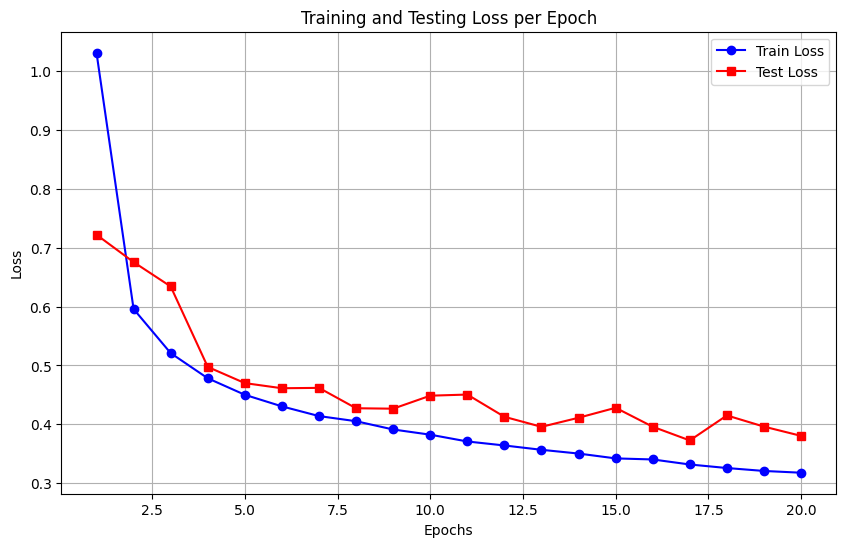

In [13]:
# === 繪圖階段 ===
plt.figure(figsize=(10, 6))
# 畫出訓練損失折線
plt.plot(range(1, num_epochs + 1), train_loss_history, label='Train Loss', color='blue', marker='o')
# 畫出測試損失折線
plt.plot(range(1, num_epochs + 1), test_loss_history, label='Test Loss', color='red', marker='s')

plt.title('Training and Testing Loss per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()  # 顯示圖例
plt.grid(True)  # 顯示網格
plt.show()  # 顯示圖表